# **Using Data from the climatedata.ca download page**

## **Create a Basic Figure with the Output of a custom climate indicator calculation**

### **Download the Data**

Follow these steps to download data from [climatedata.ca](https://climatedata.ca/download/):

1. Select your dataset (e.g., Statistically Downscaled Global Climate Projections)
2. Select your variable (e.g., Days above Tmax and Tmin)
3. Select your thresholds (e.g., Tmin 18°C and Tmax 28°C)
4. Select your type of region (e.g., Census Division)
5. Type in and select your region on the map (e.g. Longueuil)
5. Select your details:
   - Time period: 1950-2100
   - Ensemble: Full Ensemble
   - Scenarios: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
   - Percentiles: 10th, 50th, 90th
   - Temporal resolution: Seasonal
6. Select your format (CSV, 0 decimals)
7. Wait for your request to be processed. The result will be emailed to you.
8. Click on the link and save the zip on your computer.
9. Unzip the file. You should have a .csv and a .txt file. You will need the csv in step 16. 

### **Prepare your PAVICS workspace**
 Log in to PAVICS to be able to run the tutorial on your data.


10. If your are not already there, go to https://pavics.ouranos.ca/jupyter/hub/user-redirect/lab/tree/public/lavoie-public/climate-data-tutorial/tutorial-climatedata.ipynb [TODO: this will need to point to the permanent home of the notebook.]
11. Enter your username and password.
12. In the file browser on the left side, right click on tutorial-climatedata.ipynb and select copy.
13. In the file browser, go to the directory where you want to run the notebook. For example, click on the small folder icon next to the path to go back to the top of the path, then click on writable-workspace.
14. Right click in the file browser to copy the notebook there. Click on it to open it in the main window.
15. Create a directory `percentiles_output` to put your data in using the folder with a + sign icon above the file browser (not the big blue + !)
16. Click on the upward arrow above the file browser to upload your CSV file (downloaded above) to PAVICS and put it in your folder.

### **Read the data with Pandas**

<details>
<summary><strong>Additional info (click to expand)</strong></summary>
Pandas is a Python library that gives you Excel-like tables (called DataFrames) for reading, cleaning, filtering, joining, and summarizing spreadsheet-style data using code instead of clicks. It can read/write CSV and Excel files, run pivot/group and calculation operations, and automate repetitive analyses so your work is faster, reproducible, and easier to scale than manual Excel steps.
</details>

In [1]:
# import the libraries we will need
import pandas as pd # to read the csv
from matplotlib import pyplot as plt # to plot

In [2]:
# open and look at the file
# Modify the path name if necessary
df= pd.read_csv('percentiles_output/tx_tn_days_above_census_longueuil_45_458_73_375_ssp126_ssp245_ssp370_ssp585.csv')
df

,time,scenario,tx_tn_days_above_p10,tx_tn_days_above_p50,tx_tn_days_above_p90
0,1950-03-01 12:00:00,ssp126,0.0,0.0,1.0
1,1950-03-01 12:00:00,ssp245,0.0,0.0,1.0
2,1950-03-01 12:00:00,ssp585,0.0,0.0,1.0
3,1950-03-01 12:00:00,ssp370,0.0,0.0,1.0
4,1950-06-01 12:00:00,ssp245,2.0,6.0,17.0
...,...,...,...,...,...
2411,2100-09-01 12:00:00,ssp126,0.0,2.0,5.0
2412,2100-12-01 12:00:00,ssp245,NaN,NaN,NaN
2413,2100-12-01 12:00:00,ssp126,NaN,NaN,NaN
2414,2100-12-01 12:00:00,ssp370,NaN,NaN,NaN


### **Explore the Dataframe**

#### **Filtering for emissions scenarios**

Filtering by scenario lets you select the subset of model projections that correspond to one or more future pathways (SSPs). Use pandas boolean indexing with `loc` and `isin` to select rows.

<details>
<summary><strong>Examples (click to expand)</strong></summary>

- Single scenario (exact match):

  `df_ssp370 = df.loc[df['scenario'] == 'ssp370']`

  This returns only the rows where the `scenario` column equals the string `'ssp370'`.

- Multiple scenarios (choose a list):

  `df_multi = df.loc[df['scenario'].isin(['ssp245', 'ssp370'])]`

  This returns rows whose `scenario` value is in the provided list.

</details>

<details>
<summary><strong>Good to know(click to expand)</strong></summary>

- Verify available scenario names with: `df['scenario'].unique()` — it helps avoid typos.
- Ensure `df['scenario']` is of string type. If not, convert with `df['scenario'] = df['scenario'].astype(str)`.
- Chain filters (see next section) to narrow results further by season, variable, or model.

</details>

In [3]:
#  Filter a single emissions scenario
df_ssp370 = df.loc[df['scenario'] == 'ssp370']
display('Single scenario', df_ssp370)
# or multiple
df_ssp370_ssp245 = df.loc[df['scenario'].isin(['ssp370','ssp245'])]
display('Mutiple scenarios', df_ssp370_ssp245)

'Single scenario'

,time,scenario,tx_tn_days_above_p10,tx_tn_days_above_p50,tx_tn_days_above_p90
3,1950-03-01 12:00:00,ssp370,0.0,0.0,1.0
6,1950-06-01 12:00:00,ssp370,2.0,6.0,17.0
11,1950-09-01 12:00:00,ssp370,0.0,0.0,1.0
15,1950-12-01 12:00:00,ssp370,0.0,0.0,0.0
18,1951-03-01 12:00:00,ssp370,0.0,0.0,1.0
...,...,...,...,...,...
2397,2099-12-01 12:00:00,ssp370,0.0,0.0,0.0
2400,2100-03-01 12:00:00,ssp370,1.0,3.0,8.0
2404,2100-06-01 12:00:00,ssp370,43.0,58.0,76.0
2408,2100-09-01 12:00:00,ssp370,4.0,8.0,23.0


'Mutiple scenarios'

,time,scenario,tx_tn_days_above_p10,tx_tn_days_above_p50,tx_tn_days_above_p90
1,1950-03-01 12:00:00,ssp245,0.0,0.0,1.0
3,1950-03-01 12:00:00,ssp370,0.0,0.0,1.0
4,1950-06-01 12:00:00,ssp245,2.0,6.0,17.0
6,1950-06-01 12:00:00,ssp370,2.0,6.0,17.0
8,1950-09-01 12:00:00,ssp245,0.0,0.0,1.0
...,...,...,...,...,...
2407,2100-06-01 12:00:00,ssp245,29.0,43.0,62.0
2408,2100-09-01 12:00:00,ssp370,4.0,8.0,23.0
2410,2100-09-01 12:00:00,ssp245,1.0,4.0,8.0
2412,2100-12-01 12:00:00,ssp245,NaN,NaN,NaN


#### **Filtering for Specific Seasons**

Time-based filtering steps are useful when you want seasonal subsets (e.g., summer months). The workflow is:

<details>
<summary><strong>Key steps (click to expand)</strong></summary>

1. Convert the time column to datetimes: `df['time'] = pd.to_datetime(df['time'])`.
2. Extract the month number into a separate column: `df['month'] = df['time'].dt.month`.
3. Filter rows by a list of months using `isin()`.

Example — summer (June, July, August):

- `df_summer = df.loc[df['month'].isin([6, 7, 8])]`

Example — combine scenario + season in one expression:

- `df_ssp370_summ = df.loc[(df['scenario']=='ssp370') & (df['month'].isin([6,7,8]))]`

</details>

<details>
<summary><strong>Good to know (click to expand)</strong></summary>
    
- In the example we use `df['month'].isin([6,7,8])` but looking closely we see that output data has time stamps indicating the beginning of each season so `df['month'] == 6` would be appropriate as well.    
- If `df['time']` contains missing or malformed values, `pd.to_datetime()` may produce `NaT` values. Use `df = df.dropna(subset=['time'])` or handle `NaT` appropriately before extracting `month`.
- For seasons that span year boundaries (e.g., DJF), include months across the boundary: `df.loc[df['month'].isin([12,1,2])]`
- After filtering, you can inspect the result via `df_summer.head()` or `df_summer.shape` to confirm the result is as expected.

</details>

In [13]:
# put the time column in datetime format.
df['time']=pd.to_datetime(df['time'])
# add a month column
df['month'] = df['time'].dt.month
# filter for summer months (March, April, May) using loc and isin like before 
display('Filtered for summer months', )
df_summer = df.loc[df['month'].isin([6, 7, 8])] #  Locate rows where month is in the list [6, 7, 8]
df_summer

'Filtered for summer months'

,time,scenario,tx_tn_days_above_p10,tx_tn_days_above_p50,tx_tn_days_above_p90,month
4,1950-06-01 12:00:00,ssp245,2.0,6.0,17.0,6
5,1950-06-01 12:00:00,ssp126,2.0,7.0,16.0,6
6,1950-06-01 12:00:00,ssp370,2.0,6.0,17.0,6
7,1950-06-01 12:00:00,ssp585,2.0,6.0,17.0,6
20,1951-06-01 12:00:00,ssp370,3.0,8.0,17.0,6
...,...,...,...,...,...,...
2391,2099-06-01 12:00:00,ssp245,28.0,46.0,61.0,6
2404,2100-06-01 12:00:00,ssp370,43.0,58.0,76.0,6
2405,2100-06-01 12:00:00,ssp585,47.0,76.0,86.0,6
2406,2100-06-01 12:00:00,ssp126,13.0,28.0,40.0,6


### **Plotting Figures**

#### **Single Season, Single SSP Scenario**

This example demonstrates how to create a simple climate projection plot with uncertainty bands. We'll visualize the range of projections (10th-90th percentiles) alongside the central estimate (50th percentile or median).

<details>
<summary><strong>Key steps (click to expand)</strong></summary>
    
- **Define the root variable id** : In this example, my dataframe has variable columns beginning with `tx_tn_days_above`. The suffix represents the percentile.
- **Filter for emissions scenario**: Select a single scenario (e.g., SSP3-7.0).
- **Filter by season**: Apply the seasonal filter to get data for specific months.
- **Define visualization settings**: Choose a color, figure size, and shading opacity.
- **Create figure**: Set up an empty matplotlib figure and axes.
- **Plot uncertainty bands**: Use `fill_between()` to shade the area between 10th and 90th percentiles.
- **Overlay the median**: Plot the 50th percentile line on top of the shading for the central trend.
- **Add labels and title**: Include axis labels and a descriptive title.

</details>

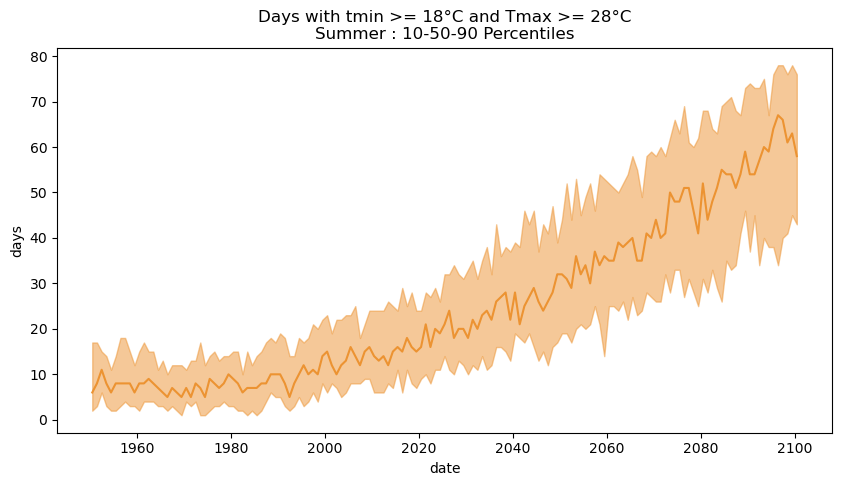

In [ ]:
# variable id, change this if you downloaded a different variable
var_root = 'tx_tn_days_above'
# Filter for ssp370
df_ssp370_summer= df.loc[df['scenario'] == 'ssp370']
# Filter the result again for summer months
df_ssp370_summer = df_ssp370_summer.loc[df_ssp370_summer['month'].isin([6, 7, 8])]
df_ssp370_summer

# Define a color for lines and shading 
# https://imagecolorpicker.com/color-code/2596be
col1 = '#ec9332' 

# set the figure size (width, height)
figure_size = (10,5)

# set the opacity for shading
alpha_shade = 0.5

# create the empty figure
fig, ax = plt.subplots(figsize=figure_size)

# plot the shading between the 10th and 90th percentile
plt.fill_between(df_ssp370_summer.time, # x-axis
                 df_ssp370_summer[f"{var_root}_p10"], # bottom y ; var_root with '_p10' added
                 df_ssp370_summer[f"{var_root}_p90"], # top y ; var_root with '_p90' added
                 color=col1,
                 alpha=alpha_shade # shade
                )
# plot the median (p50) over top of the shading
plt.plot(df_ssp370_summer.time, # x-axis
         df_ssp370_summer[f"{var_root}_p50"], # y-axis; var_root with '_p50'
         color=col1)        

# add label and title
plt.ylabel("days")
plt.xlabel("date")
t = plt.title('Days with tmin >= 18°C and Tmax >= 28°C\nSummer : 10-50-90 Percentiles')

#### **Multiple SSP Scenarios on the Same Graph**

Comparing different emissions scenarios on a single plot helps visualize how climate projections differ across scenarios. This example plots two scenarios (SSP2-4.5 and SSP3-7.0) simultaneously.

<details>
<summary><strong>Key steps (click to expand)</strong></summary>

- **Filter the data**: Select multiple scenarios using `isin()` method (e.g., 'ssp370' and 'ssp245').
- **Filter by season**: Apply the same seasonal filter as before.
- **Define colors**: Use a dictionary to assign distinct colors to each scenario for clarity.
- **Set up the figure**: Configure size and opacity settings.
- **Loop through scenarios**: Use a `for` loop to iteratively plot each scenario.
- **Add transparency**: Use shading (`fill_between`) between the 10th and 90th percentiles with transparency.
- **Overlay the median**: Plot the 50th percentile line on top of the shading.
- **Add legend**: Include a legend to identify which color represents which scenario.

</details>

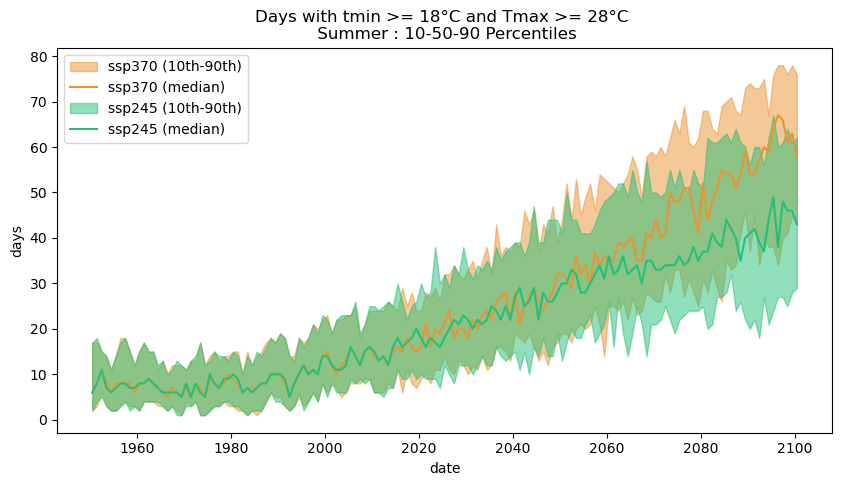

In [ ]:
# variable id
var_root = 'tx_tn_days_above'

# Filter for ssp370 and ssp245
df_summer= df.loc[df['scenario'].isin(['ssp370', 'ssp245'])]

# Filter the result again for summer months
df_summer = df_summer.loc[df_summer['month'].isin([6, 7, 8])]
df_summer

# # Define colors for lines and shading  
# # see : https://imagecolorpicker.com/color-code/2596be for more options
col_dict = {
            'ssp370':'#ec9332',  # same color as before
            'ssp245':'#24bf78' # green color for ssp245
           }
# # set the figure size (width, height)
figure_size = (10,5)
# # set the opacity for shading
alpha_shade = 0.5
# # create the figure
fig, ax = plt.subplots(figsize=figure_size)

# loop through each scenario to plot
for scenario in ['ssp370', 'ssp245']:
    # dynamically create a dataframe for the scenario of interest
    df_scen = df_summer.loc[df_summer['scenario'] == scenario]

    # plot the shading between the 10th and 90th percentile
    plt.fill_between(df_scen.time, # x-axis
                     df_scen[f"{var_root}_p10"], # bottom y
                     df_scen[f"{var_root}_p90"], # top y
                     color=col_dict[scenario], # color from dictionary
                     alpha=alpha_shade, # shade
                     label = f'{scenario} (10th-90th)' # add label for legend
                    )
    
    # plot the median (p50) over top of the shading
    plt.plot(df_scen.time, 
             df_scen[f"{var_root}_p50"],
             color=col_dict[scenario], 
             label=f'{scenario} (median)', 
             )

# add overall label and title
plt.ylabel("days")
plt.xlabel("date")
t=plt.title('Days with tmin >= 18°C and Tmax >= 28°C \n Summer : 10-50-90 Percentiles')
# add the legend
l=plt.legend()

## **Advanced: Custom ensemble with individual simulations**

### **Download the data**
Same steps as above, but on ***step 5, don't select any percentiles*** (in order to get the values for all the models).
* create a `simulations_output` subfolder in your workspace and upload the output there

### **Open and covert the data**

- Convert the CSV table into a compact xarray dataset: `ds_model` organized by `scenario` and `time`.
- Additional libraries required: `xscen`, `xarray`.

<details>
<summary><strong>Key steps (click to expand)</strong></summary>

- Read the CSV into pandas and convert the `time` column as datetimes.
- For each emissions scenario in the table:
  - select rows for that scenario and convert to an xarray dataset.
  - set `time` as a coordinate and swap the index to the `time` dimension.
  - add the scenario as a coordinate and expand it into a new `scenario` dimension.
  - drop temporary index columns used during the conversion.
- Combine all per-scenario datasets with `xr.concat(..., dim='scenario')` to get a 2D dataset (scenario × time).
- Result `ds_model` is ready for analysis: plotting, climatologies and custom ensemble statistics (e.g., percentiles).
</details>

<details>
<summary><strong>Additional info (click to expand)</strong></summary>

- xarray is a Python library for working with labeled multi-dimensional arrays (very similar to pandas for spreadsheets but extended to any number of dimensions).
- xscen is a higher-level, climate-focused Python toolkit built on top of xarray that helps prepare, standardize, and process climate datasets.

</details>


In [7]:
# extra libraries needed
import xscen as xs
import xarray as xr

# open the file
df_model = pd.read_csv('simulations_output/tx_tn_days_above_census_longueuil_45_458_73_375_ssp126_ssp245_ssp370_ssp585.csv')
# put the time column in datetime format. It will be easier to plot.
df_model['time']=pd.to_datetime(df_model['time'])

# # For advanced calculations, it will easier to transform the data to an xarray dataset.
# create one xarray dataset per scenario
ds_list = []
for ssp in df_model['scenario'].unique():
    dstmp = df_model.loc[df_model['scenario'] == ssp].to_xarray() # filter and convert to xarray
    dstmp.set_coords(['time']) # set time as coordinate
    dstmp = dstmp.swap_dims({"index": "time"}) # swap index for time dimension
    dstmp = dstmp.assign_coords({'scenario': ssp}).expand_dims('scenario') # add scenario as a coordinate and dimension
    dstmp = dstmp.drop_vars(['index']) # drop the index variable
    ds_list.append(dstmp) # add to list
# combine all scenarios into a single xarray dataset
ds_model = xr.concat(ds_list, dim='scenario')
ds_model # 2d dataset with time and scenario dimensions

<xarray.Dataset> Size: 469kB
Dimensions:                                                                                                                                (
                                                                                                                                            scenario: 4,
                                                                                                                                            time: 604)
Coordinates:
  * time                                                                                                                                   (time) datetime64[ns] 5kB ...
  * scenario                                                                                                                               (scenario) <U6 96B ...
Data variables: (12/24)
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_access_cm2_historical__r1i1p1f1_gn_19500101_21001231_sub     (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_access_esm1_5_historical__r1i1p1f1_gn_19500101_21001231_sub  (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_bcc_csm2_mr_historical__r1i1p1f1_gn_19500101_21001231_sub    (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_canesm5_historical__r1i1p2f1_gn_19500101_21001231_sub        (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_cmcc_esm2_historical__r1i1p1f1_gn_19500101_21001231_sub      (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_cnrm_cm6_1_historical__r1i1p1f2_gr_19500101_21001231_sub     (scenario, time) float64 19kB ...
    ...                                                                                                                                     ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_mpi_esm1_2_lr_historical__r1i1p1f1_gn_19500101_21001231_sub  (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_mri_esm2_0_historical__r1i1p1f1_gn_19500101_21001231_sub     (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_noresm2_lm_historical__r1i1p1f1_gn_19500101_21001231_sub     (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_noresm2_mm_historical__r1i1p1f1_gn_19500101_21001231_sub     (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_taiesm1_historical__r1i1p1f1_gn_19500101_21001231_sub        (scenario, time) float64 19kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_ukesm1_0_ll_historical__r1i1p1f2_gn_19500101_21001230_sub    (scenario, time) float64 19kB ...

### **Plot the data**

#### Single Season, Single SSP Scenario — all individual model simulations

This visualization plots output of each model in the ensemble for a chosen season and scenario (for example: summer (JJA), ssp370). It shows model-to-model spread (inter-model variability). This is *not* an ensemble percentile plot — it displays each model separately so you can inspect individual behaviour.

<details>
<summary><strong>Key steps (click to expand)</strong></summary>

- **Choose season & scenario** — pick the season (e.g., JJA) and the scenario (e.g., ssp370).
- **Select the subset** — use `ds_model.sel(...)` or boolean selection to extract the season + scenario slice.
- **Decide color strategy** — either use a single muted color for all models (less visual clutter) or let each model have its own color.
- **Adjust figure aesthetics** — set `figure_size`, `linewidth`, and `alpha` so overlapping lines remain readable.
- **Plot each model** — loop through model variables and draw each timeseries on the same axes.
- **Annotate** — add an explanatory title and y-axis label that explicitly say these are individual model traces.

</details>

<details>
<summary><strong>Tips (click to expand)</strong></summary>


- To reduce noise, use a low `linewidth` (e.g., 0.3–1.0) and moderate transparency (`alpha` ≈ 0.6–0.8).
- If you want an ensemble summary (median/percentiles), use `xs.ensemble_stats` (see the later section) and plot the percentiles on top of the individual traces.
- For a quick sanity check, display the subset (`ds_ssp370_summer` or `ds_ssp370_summer.data_vars`) before plotting to confirm you selected the expected models/time range.
</details>

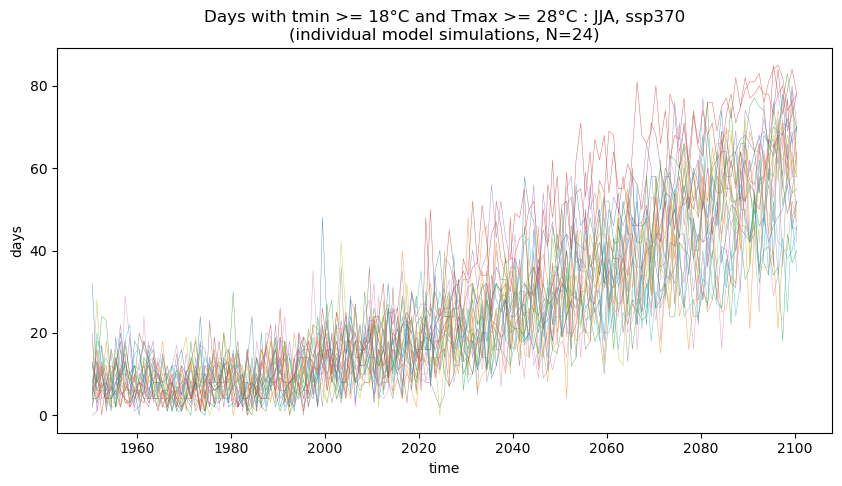

In [15]:
# plot each of the 24 models
season = 'JJA' # summer (June, July, August)
ssp = 'ssp370'
ds_ssp370_summer = ds_model.sel(time=ds_model.time.dt.season == season, scenario=ssp)
ds_ssp370_summer

# # set the figure size (width, height)
figure_size = (10,5)
# # set the opacity for shading
alpha_shade = 0.5
# # create the figure
fig, ax = plt.subplots(figsize=figure_size)

# color for the lines
# col_model = '#818789' # uncomment to make all models the same color
col_model = None # comment to make all models the same color

##############################################################
# Typically no user changes needed below this point 

# loop through each model and plot each one
for vv in ds_ssp370_summer.data_vars:
    ds_ssp370_summer[vv].plot(color=col_model, linewidth=0.35, alpha=0.7, ax=ax)
# add label and title
plt.ylabel("days")
t = plt.title(f'Days with tmin >= 18°C and Tmax >= 28°C : {season}, {ssp}\n(individual model simulations, N=24)')

### **Compute climatological means**

This step computes 30‑year climatologies using a sliding window and returns a compact dataset that is easier to analyze.

<details>
<summary><strong>Parameters & what the call does (click to expand)</strong></summary>

- `window=30` — computes the climatological statistic (here: mean) over 30‑year windows.
- `stride=10` — moves the 30‑year window in 10‑year increments. For example, with data from 1950–2100 the windows will typically be 1951–1980, 1961–1990, 1971–2000, etc. Each window is summarized by the chosen operation.
- `op='mean'` — the statistic applied to each window (here the arithmetic mean).
- `horizons_as_dim=True` — returns the collection of windows as a new dimension (named `horizon`) instead of combining them into a single aggregated time coordinate.
- `periods=[start_year, end_year]` — specifies the total time slice over which to apply the sliding window. For example, `periods=[1951, 2100]` means only use data from year 1951 to 2100 (inclusive) when creating windows. This is useful to exclude early or late data that may be incomplete or undesired. If not specified, all available time steps are used.
- With `window=30` and `stride=10` you get overlapping climatologies that show how the 30‑year average evolves through time while keeping the smoothing of a 30‑year window.
</details>

<details>
<summary><strong>Interpretation, examples & notes (click to expand)</strong></summary>

What is added to the output dataset:

- A `horizon` dimension/coordinate: each index along `horizon` corresponds to one 30‑year window (the coordinate typically represents the central year or a label for that window). You can inspect `ds_clim.horizon` to see the horizon labels and use `ds_clim.sel(horizon=...)` to select a specific window.
- A `season` coordinate/dimension: climatologies are usually computed per calendar season (DJF, MAM, JJA, SON) — the result includes a `season` axis so you can compare seasonal climatologies across horizons.



Quick examples:

- List horizons:

  `print(ds_clim.horizon)`

- Select the climatology or interest:

  `ds_clim.sel(horizon='2041-2070')`

- Select a specific season and horizon:

  `ds_clim.sel(season='JJA', horizon='2041-2070')`

Good to know:

- The `periods` parameter is useful to crop the input data to a time range of interest (e.g., excluding historical data before 1950).
- For seasons spanning year boundaries (DJF), check how the function defines the season boundaries; results are typically grouped by pandas/xarray seasonal conventions.
- If you want non-overlapping windows, set `stride=window` (e.g., stride=30).

</details>

Result:
- `ds_clim` contains the 30‑year mean values for each model/variable, for each season, and for each horizon (window).

Plotting notes:
- In this specific example, we make a subplot for three seasons of interest (MAM, JJA, SON), allowing comparison the climatological means for each season side by side.

<xarray.Dataset> Size: 41kB
Dimensions:                                                                                                                                          (
                                                                                                                                                      horizon: 13,
                                                                                                                                                      season: 4,
                                                                                                                                                      scenario: 4)
Coordinates:
    time                                                                                                                                             (horizon, season) datetime64[ns] 416B ...
  * scenario                                                                                                                                         (scenario) <U6 96B ...
  * season                                                                                                                                           (season) <U3 48B ...
  * horizon                                                                                                                                          (horizon) <U9 468B ...
Data variables: (12/24)
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_access_cm2_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean     (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_access_esm1_5_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean  (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_bcc_csm2_mr_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean    (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_canesm5_historical__r1i1p2f1_gn_19500101_21001231_sub_clim_mean        (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_cmcc_esm2_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean      (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_cnrm_cm6_1_historical__r1i1p1f2_gr_19500101_21001231_sub_clim_mean     (horizon, season, scenario) float64 2kB ...
    ...                                                                                                                                               ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_mpi_esm1_2_lr_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean  (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_mri_esm2_0_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean     (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_noresm2_lm_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean     (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_noresm2_mm_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean     (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_taiesm1_historical__r1i1p1f1_gn_19500101_21001231_sub_clim_mean        (horizon, season, scenario) float64 2kB ...
    tx_tn_days_above:ensemble_grid_point_tx_tn_days_above_day_mbcn_pcic_blend_ukesm1_0_ll_historical__r1i1p1f2_gn_19500101_21001230_sub_clim_mean    (horizon, season, scenario) float64 2kB ...
Attributes:
    cat:processing_level:  climatology

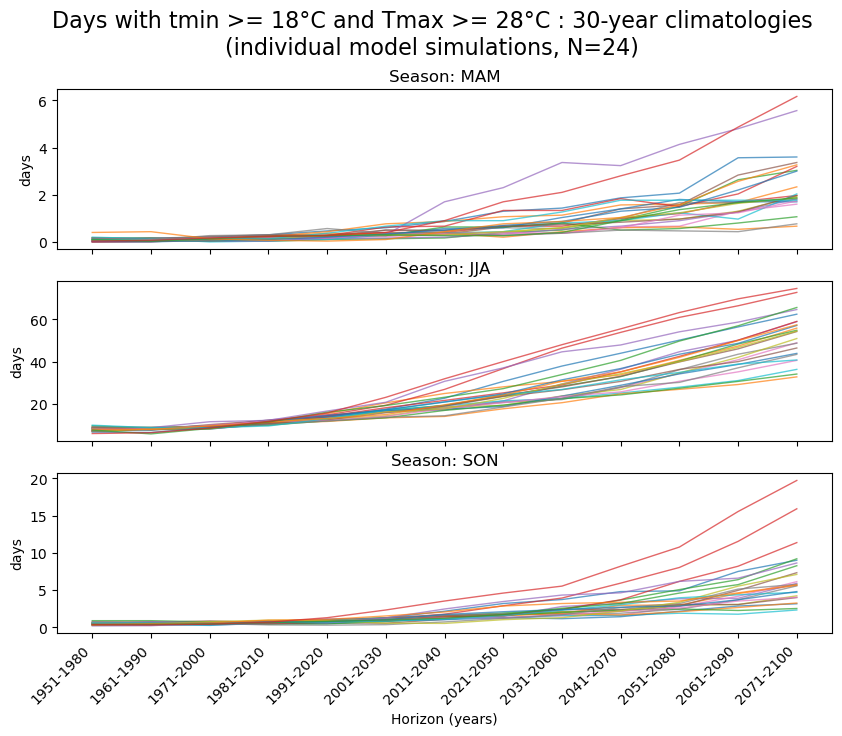

In [16]:


# # set the figure size (width, height)
figure_size = (10,8)
# # set the opacity for shading
alpha_shade = 0.5

# # create the figure with 3 subplots (one for each season of interest)
fig, axs = plt.subplots(3, 1, figsize=figure_size)


# color for the lines
# col_model = '#818789' # uncomment to make all models the same color
col_model = None # comment to make all models the same color

# Seasons of interest
seasons = ['MAM','JJA', 'SON'] # Skip winter (DJF); not really useful for this indicator in southern QC

ds_clim=xs.climatological_op(
    ds=ds_model,
    horizons_as_dim=True, # keep the horizons as a dimension
    op='mean', # Choose the mean operation
    window=30, # apply over 30 window
    stride=10, # apply every 10 years
    periods = [1951, 2100]
)

display(ds_clim)

##############################################################
# Typically no user changes needed below this point 

# loop through each season to create a subplot
for i, season in enumerate(seasons):
    ax = axs.flatten()[i]
    ds_tmp = ds_clim.sel(season=season, scenario='ssp370')
    # # loop through each model and plot each one
    for vv in ds_tmp.data_vars:
        ds_tmp[vv].plot(color=col_model, linewidth=1.0, alpha=0.7, ax=ax)
    ax.set_title(f'Season: {season}')
    ax.set_ylabel('days')
    ax.set_xlabel('Horizon (years)')
# rotate xlabels
fig.autofmt_xdate(rotation=45)
# add overall title
t = plt.suptitle('Days with tmin >= 18°C and Tmax >= 28°C : 30-year climatologies\n(individual model simulations, N=24)', fontsize=16)


### **Compute custom ensemble statistics**

This step computes a custom set of percentiles from the ensemble of individual model simulations and creates a visualization with layered uncertainty envelopes.

<details>
<summary><strong>What the code does (click to expand)</strong></summary>

- **Compute percentiles**: Uses `xs.ensemble_stats()` to calculate the 2nd, 5th, 10th, 25th, 50th, 75th, 90th, 95th and 98th percentiles across all model simulations.
- **Result dataset**: Creates a compact xarray dataset (`ds_ens`) with ensemble statistics that represent the full spread of model projections.
- **Visualization approach**: Creates shaded envelopes showing symmetric pairs of percentiles:
  - 5th–95th percentile (outermost envelope)
  - 10th–90th percentile
  - 25th–75th percentile (innermost envelope)
- **Median overlay**: Plots the 50th percentile (median) as a line on top of the shaded regions.
- **Transparency layering**: Uses low opacity (`alpha=0.2`) on each envelope so overlapping regions show the combined probability density.

</details>

<details>
<summary><strong>Key parameters in this example (click to expand)</strong></summary>

- `cust_perc = [5, 10, 25, 50, 75, 90, 95]` — the custom percentiles to compute.
- `seas = 'JJA'` — the season of interest (summer in this case).
- `scen = 'ssp370'` — the scenario to visualize (SSP3-7.0).
- `alpha_shade = 0.2` — transparency level for shaded envelopes (low alpha allows layering).
- `shade_pairs` — automatically pairs percentiles symmetrically (5th with 95th, 10th with 90th, etc.) for visual interpretation.

</details>

<details>
<summary><strong>Interpretation & tips (click to expand)</strong></summary>

- **Darker shaded regions** indicate higher probability (overlap of multiple percentile pairs).
- **Lighter shaded regions** at the extremes represent the full range of model spread (5th–95th).
- The **median line** shows the central tendency across the ensemble.
- You can easily adapt `seas` and `scen` to visualize different seasons or scenarios.

</details>

/opt/conda/envs/birdy/lib/python3.11/site-packages/xclim/core/utils.py:477: RuntimeWarning: All-NaN slice encountered
Unable to generate a new id for the dataset. Got single positional indexer is out-of-bounds.


'Ensemble percentile dataset'

<xarray.Dataset> Size: 179kB
Dimensions:               (scenario: 4, time: 604)
Coordinates:
  * time                  (time) datetime64[ns] 5kB 1950-03-01T12:00:00 ... 2...
  * scenario              (scenario) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
Data variables:
    tx_tn_days_above_p02  (scenario, time) float64 19kB 0.0 0.92 ... 2.38 nan
    tx_tn_days_above_p05  (scenario, time) float64 19kB 0.0 2.0 0.0 ... 4.15 nan
    tx_tn_days_above_p10  (scenario, time) float64 19kB 0.0 2.3 0.0 ... 5.9 nan
    tx_tn_days_above_p25  (scenario, time) float64 19kB 0.0 5.0 0.0 ... 10.0 nan
    tx_tn_days_above_p50  (scenario, time) float64 19kB 0.0 6.5 0.0 ... 12.5 nan
    tx_tn_days_above_p75  (scenario, time) float64 19kB 0.0 12.5 ... 18.0 nan
    tx_tn_days_above_p90  (scenario, time) float64 19kB 1.0 16.4 ... 21.4 nan
    tx_tn_days_above_p95  (scenario, time) float64 19kB 1.0 17.85 ... 23.7 nan
    tx_tn_days_above_p98  (scenario, time) float64 19kB 1.54 26.1 ... 24.54 nan
Attributes:
    cat:processing_level:  ensemble
    ensemble_size:         24

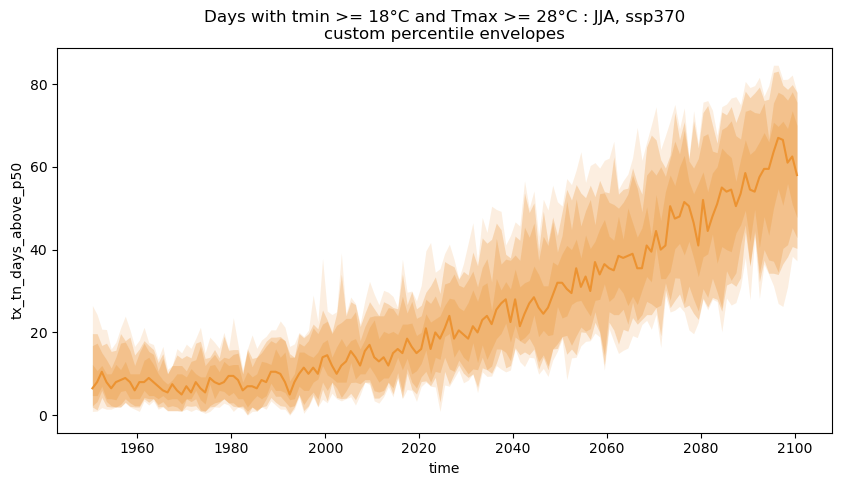

In [17]:
var_root = 'tx_tn_days_above'

cust_perc = [2, 5, 10, 25, 50, 75, 90, 95, 98]  # list of percentiles of interest
ds_ens=xs.ensemble_stats(
    datasets= [ds_model[[var]].rename({var:var_root}) for var in ds_model.data_vars], # list of all model,
    statistics= {"ensemble_percentiles": {"values": cust_perc}} # compute custom percentiles
)
display('Ensemble percentile dataset', ds_ens)

seas = 'JJA'
scen = 'ssp370'
# # Define colors for lines and shading  
# # https://imagecolorpicker.com/color-code/2596be
col_dict = {
            'ssp370':'#ec9332',  # same color as before
            'ssp245':'#24bf78' # green color for ssp245
           }
# # set the figure size (width, height)
figure_size = (10,5)
# # set the opacity for shading
alpha_shade = 0.15


##############################################################
# Typically no user changes needed below this point

# # create the figure
fig, ax = plt.subplots(figsize=figure_size)

# creat pair of percentiles for shading : lowest matched with highest, second lowest with second highest, etc.
nperc = len(cust_perc) - 1
shade_pairs = [f"p{str(c).zfill(2)}" for c in cust_perc]
shade_pairs = [(s, shade_pairs[nperc - ii]) for ii, s in enumerate(shade_pairs[:-1]) if s != shade_pairs[nperc - ii]]

# create a dataset for the season of interest
ds_ens_seas = ds_ens.sel(time=ds_ens.time.dt.season == seas)
# Create the shading for each pair of percentiles
for shade_pair in shade_pairs:
    plt.fill_between(ds_ens_seas.sel(scenario=scen).time, # x-axis
                     ds_ens_seas.sel(scenario=scen)[f"{var_root}_{shade_pair[0]}"], # bottom y
                     ds_ens_seas.sel(scenario=scen)[f"{var_root}_{shade_pair[1]}"], # top y
                     color=col_dict[scen], # color from dictionary
                     alpha=alpha_shade, # shade
                     linewidth=0 # to remove borders on the shading
                    )
# plot the median over all the shading
ds_ens_seas.sel(scenario=scen)[f"{var_root}_p50"].plot(x='time', color=col_dict[scen], ax=ax)
# add a title
t = plt.title(f'Days with tmin >= 18°C and Tmax >= 28°C : {seas}, {scen}\ncustom percentile envelopes')